In [1]:
import gc
import time
import gseapy as gp
import textwrap

from pathlib import Path

import numpy as np
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.multitest import multipletests

import pandas as pd

import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn3
from matplotlib.lines import Line2D
import matplotlib as mpl

from upsetplot import from_contents, generate_counts, UpSet, plot, from_indicators

import seaborn as sns

# import anndata as ad
# import scanpy as sc

%matplotlib inline

In [2]:
## FDR Calculation Function ##

def fdr_per_celltype(dge_df):
    """Add FDR-adjusted p-values and significance per cell type."""
    dge_df['p.adjusted'] = None
    dge_df['significant_fdr'] = False
    
    for celltype, group in dge_df.groupby('assay'):
        rejected, pvals_corrected, _, _ = multipletests(group['p.value'], method='fdr_bh')
        dge_df.loc[group.index, 'p.adjusted'] = pvals_corrected
        dge_df.loc[group.index, 'significant_fdr'] = rejected
    
    return dge_df

In [3]:
## Read in DEG Lists ##

CSV_PATH = '/mnt/sdb/scz_meta_analysis_processed/dge_signatures/dreamlet_dges/disease_analyses/'

# by manuscript #
dge_fernando = pd.read_csv(Path(CSV_PATH) / 'dreamlet_fernando_dge_scz_results.csv')
dge_shin = pd.read_csv(Path(CSV_PATH) / 'dreamlet_shin_dge_scz_results.csv')
dge_purcell = pd.read_csv(Path(CSV_PATH) / 'dreamlet_purcell_dge_scz_results.csv')
dge_sebastian = pd.read_csv(Path(CSV_PATH) / 'dreamlet_sebastian_dge_scz_results.csv')
dge_sawada = pd.read_csv(Path(CSV_PATH) / 'dreamlet_sawada_dge_scz_results.csv')
dge_notaras = pd.read_csv(Path(CSV_PATH) / 'dreamlet_notaras_dge_scz_results.csv')
dge_rao = pd.read_csv(Path(CSV_PATH) / 'dreamlet_rao_dge_scz_results.csv')
dge_walsh_22q11 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_walsh_22q11_dge_scz_results.csv')
dge_walsh_15q13 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_walsh_15q13_dge_scz_results.csv')

# by disease #
dge_nrxn1 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_nrxn1_combined.csv')
dge_22q11 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_22q11_combined.csv')
dge_idiopathic = pd.read_csv(Path(CSV_PATH) / 'dreamlet_idiopathic_combined.csv')
dge_15q13 = dge_walsh_15q13
dge_3q29 = dge_purcell

In [4]:
# Make Assay ID #

# Put all dataframes in a dictionary
dge_dfs = {
    'dge_fernando': dge_fernando,
    'dge_shin': dge_shin,
    'dge_purcell': dge_purcell,
    'dge_sebastian': dge_sebastian,
    'dge_sawada': dge_sawada,
    'dge_notaras': dge_notaras,
    'dge_rao': dge_rao,
    'dge_walsh_22q11': dge_walsh_22q11,
    'dge_walsh_15q13': dge_walsh_15q13,
    'dge_nrxn1': dge_nrxn1,
    'dge_22q11': dge_22q11,
    'dge_idiopathic': dge_idiopathic,
    'dge_15q13': dge_15q13,
    'dge_3q29': dge_3q29
}

# Add assay_ID column to each
for name, df in dge_dfs.items():
    df['assay_ID'] = df['assay'].astype(str) + ' | ' + df['ID'].astype(str)

In [5]:
## Calculate FDR ##

dge_nrxn1 = fdr_per_celltype(dge_nrxn1)
dge_22q11 = fdr_per_celltype(dge_22q11)
dge_idiopathic = fdr_per_celltype(dge_idiopathic)

In [6]:
## Calculate Significant Gene Lists ##

# refine metaanalysis dataframes to significant hits across all studies 
significant_nrxn1_df = dge_nrxn1[(dge_nrxn1['p.adjusted'] < 0.05) & (dge_nrxn1['n.studies'] == 2)]
significant_22q11_df = dge_22q11[(dge_22q11['p.adjusted'] < 0.05) & (dge_22q11['n.studies'] == 3)]
significant_idiopathic_df = dge_idiopathic[(dge_idiopathic['p.adjusted'] < 0.05) & (dge_idiopathic['n.studies'] == 2)]

# make significnat gene lists
significant_nrxn1 = significant_nrxn1_df['ID'].tolist()
significant_22q11 = significant_22q11_df['ID'].tolist()
significant_idiopathic = significant_idiopathic_df['ID'].tolist()

# make sets from lists #
set_nrxn1 = set(significant_nrxn1)
set_22q11 = set(significant_22q11)
set_idiopathic = set(significant_idiopathic)

# make overlap lists ##
set_22q11_nrxn1 = set_22q11.intersection(set_nrxn1) 
set_22q11_idiopathic = set_22q11.intersection(set_idiopathic) 
set_nrnxn1_idiopathic = set_nrxn1.intersection(set_idiopathic) 

In [7]:
dge_15q13[(dge_15q13['adj.P.Val'] < 0.05)]

,assay,ID,logFC,AveExpr,t,P.Value,adj.P.Val,B,z.std,dataset,assay_ID


In [8]:
dge_3q29[(dge_3q29['adj.P.Val'] < 0.05)][['assay']].value_counts()

assay                                     
Radial Glia SOX2+VIM+FABP7+                   24
Proliferative Radial Glia SOX2+HES6+TOP2A+     3
IPC EOMES+NEUROG2+PAX6+                        1
Mesenchymal-like cells VIM+VCAN+SPARC+         1
Mixed Neurons FGF12+GRIN2B+CAMK2B+             1
Name: count, dtype: int64

In [9]:
def add_directional_consistency(df):
    # Remove duplicate columns
    df = df.loc[:, ~df.columns.duplicated()].copy()
    
    # Identify logFC columns
    logfc_cols = [col for col in df.columns if col.startswith('logFC')]
    
    def check_direction(row):
        vals = row[logfc_cols].dropna()
        
        if len(vals) <= 1:
            return np.nan  # not enough data
        
        signs = np.sign(vals)
        signs = signs[signs != 0]  # optionally ignore zeros
        
        if len(signs) == 0:
            return np.nan
        
        return len(set(signs)) == 1  # True if all same sign
    
    # Add new column
    df['directionally_consistent'] = df.apply(check_direction, axis=1)
    
    return df

In [10]:
## Examining 22q11 Meta-Analysis ##

dge_shin_rao = dge_shin.merge(dge_rao, left_on=['assay', 'ID', 'assay_ID'],
                              right_on=['assay', 'ID', 'assay_ID'], how='inner', suffixes=['_shin', '_rao'])

dge_walsh_22q11_renamed = dge_walsh_22q11.add_suffix('_walsh')
dge_walsh_22q11_renamed = dge_walsh_22q11_renamed.rename(columns={'assay_walsh': 'assay', 'ID_walsh': 'ID', 'assay_ID_walsh':'assay_ID'})

dge_shin_rao_walsh_22q11 = dge_shin_rao.merge(dge_walsh_22q11_renamed,
                                              left_on=['assay', 'ID', 'assay_ID'],
                                              right_on=['assay', 'ID', 'assay_ID'], how='inner')

significant_22q11_df_logfc = significant_22q11_df.merge(dge_shin_rao_walsh_22q11[['assay', 'ID', 'assay_ID', 
                                                                            'logFC_rao','logFC_shin', 'logFC_walsh']],
                                                  left_on=['assay', 'ID', 'assay_ID'], 
                                                  right_on=['assay', 'ID', 'assay_ID'], how='left') 

significant_22q11_df_logfc = add_directional_consistency(significant_22q11_df_logfc)

logfc_cols_22q11 = [i for i in significant_22q11_df_logfc.columns if 'logFC' in i]
significant_22q11_df_logfc['mean_logFC'] = significant_22q11_df_logfc[logfc_cols_22q11].mean(axis=1)

dc_significant_22q11_df_logfc = significant_22q11_df_logfc[significant_22q11_df_logfc['directionally_consistent'] == True]

significant_22q11_df_logfc['directionally_consistent'].mean()

0.5676126878130217

In [11]:
## Examining NRXN1 Meta-Analysis ##

dge_sebastian_fernando = dge_sebastian.merge(dge_fernando, left_on=['assay', 'ID', 'assay_ID'],
                              right_on=['assay', 'ID', 'assay_ID'], how='inner', suffixes=['_sebastian', '_fernando'])

significant_nrxn1_df_logfc = significant_nrxn1_df.merge(dge_sebastian_fernando[['assay', 'ID', 'assay_ID', 
                                                                            'logFC_sebastian', 'logFC_fernando']],
                                                                            left_on=['assay', 'ID', 'assay_ID'], 
                                                                            right_on=['assay', 'ID', 'assay_ID'], how='left') 

significant_nrnx1_df_logfc = add_directional_consistency(significant_nrxn1_df_logfc)

logfc_cols_nrxn1 = [i for i in significant_nrnx1_df_logfc.columns if 'logFC' in i]
significant_nrnx1_df_logfc['mean_logFC'] = significant_nrnx1_df_logfc[logfc_cols_nrxn1].mean(axis=1)

dc_significant_nrxn1_df_logfc = significant_nrnx1_df_logfc[significant_nrnx1_df_logfc['directionally_consistent'] == True]

significant_nrnx1_df_logfc['directionally_consistent'].mean()

0.7546972860125261

In [12]:
## Examining Idiopathic Meta-Analysis ##

dge_sawada_notaras = dge_sawada.merge(dge_notaras, left_on=['assay', 'ID', 'assay_ID'],
                              right_on=['assay', 'ID', 'assay_ID'], how='inner', suffixes=['_sawada', '_notaras'])

significant_idiopathic_df_logfc = significant_idiopathic_df.merge(dge_sawada_notaras[['assay', 'ID', 'assay_ID', 
                                                                                'logFC_sawada', 'logFC_notaras']],
                                                                                left_on=['assay', 'ID', 'assay_ID'], 
                                                                                right_on=['assay', 'ID', 'assay_ID'], how='left') 

significant_idiopathic_df_logfc = add_directional_consistency(significant_idiopathic_df_logfc)

logfc_cols_idiopathic = [i for i in significant_idiopathic_df_logfc.columns if 'logFC' in i]
significant_idiopathic_df_logfc['mean_logFC'] = significant_idiopathic_df_logfc[logfc_cols_idiopathic].mean(axis=1)

dc_significant_idiopathic_df_logfc = significant_idiopathic_df_logfc[significant_idiopathic_df_logfc['directionally_consistent'] == True]

significant_idiopathic_df_logfc['directionally_consistent'].mean()

0.744927536231884

In [13]:
# ## Check Overlap Between Directionally Consistent MetaAnalyzed DataFrames ##

# df_22q11_to_merge = dc_significant_22q11_df_logfc.copy()
# df_22q11_to_merge.columns = [i+'_22q11' for i in df_22q11_to_merge.columns]

# df_nrxn1_to_merge = dc_significant_nrxn1_df_logfc.copy()
# df_nrxn1_to_merge.columns = [i+'_nrxn1' for i in df_nrxn1_to_merge.columns]

# df_idiopathic_to_merge = dc_significant_idiopathic_df_logfc.copy()
# df_idiopathic_to_merge.columns = [i+'_idiopathic' for i in dc_significant_idiopathic_df_logfc.columns]

# df_22q11_nrxn1 = df_22q11_to_merge.merge(df_nrxn1_to_merge, 
#                                          right_on=['ID_nrxn1', 'assay_nrxn1'], 
#                                          left_on=['ID_22q11', 'assay_22q11'])

# df_22q11_idiopathic = df_22q11_to_merge.merge(df_idiopathic_to_merge, 
#                                               right_on=['ID_idiopathic', 'assay_idiopathic'], 
#                                               left_on=['ID_22q11', 'assay_22q11'])

# df_nrxn1_idiopathic = df_nrxn1_to_merge.merge(df_idiopathic_to_merge, 
#                                               right_on=['ID_idiopathic', 'assay_idiopathic'], 
#                                               left_on=['ID_nrxn1', 'assay_nrxn1'])

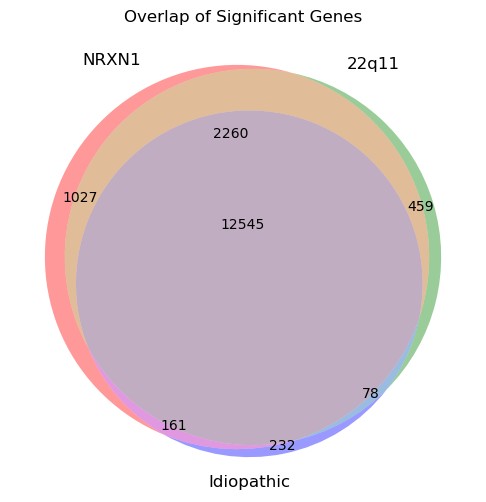

In [14]:
## Venn Diagram Of Overlap CellType Agonstic ##

## No Directional Consistency Demands ##

# --- Venn diagram for all three lists ---
plt.figure(figsize=(8, 6))
venn3([set(dge_nrxn1['ID']), set(dge_22q11['ID']), set(dge_idiopathic['ID'])],
      set_labels=('NRXN1', '22q11', 'Idiopathic'))
plt.title("Overlap of Significant Genes")
plt.show()

In [15]:
# ## Overlap Conditional On Directional Consistency Within Diseases ##

# # Convert to Sets #
# dge_nrxn1_set = set(dc_significant_nrxn1_df_logfc['ID'])
# dge_22q11_set = set(dc_significant_22q11_df_logfc['ID'])
# dge_idiopathic_set = set(dc_significant_idiopathic_df_logfc['ID'])

# # Custom colors
# COLORS = {
#     "NRXN1": "#fc8d62ff",
#     "22q11": "#8da0cbff",
#     "Idiopathic": "#66c2a5ff"
# }
   
# plt.figure(figsize=(8, 6))

# v = venn3(
#     [dge_nrxn1_set, dge_22q11_set, dge_idiopathic_set],
#     set_labels=('NRXN1', '22q11', 'Idiopathic')
# )

# # MAIN SET COLORS + EDGES
# v.get_patch_by_id('100').set_color(COLORS["NRXN1"])
# v.get_patch_by_id('100').set_alpha(0.6)
# v.get_patch_by_id('100').set_edgecolor('black')
# v.get_patch_by_id('100').set_linewidth(1.5)

# v.get_patch_by_id('010').set_color(COLORS["22q11"])
# v.get_patch_by_id('010').set_alpha(0.6)
# v.get_patch_by_id('010').set_edgecolor('black')
# v.get_patch_by_id('010').set_linewidth(1.5)

# v.get_patch_by_id('001').set_color(COLORS["Idiopathic"])
# v.get_patch_by_id('001').set_alpha(0.6)
# v.get_patch_by_id('001').set_edgecolor('black')
# v.get_patch_by_id('001').set_linewidth(1.5)

# # LABEL STYLING

# for text in v.set_labels:
#     if text:
#         text.set_fontsize(15)

# for text in v.subset_labels:
#     if text:
#         text.set_fontsize(15)

# plt.title("Overlap of Significant Genes")
# plt.tight_layout()
# plt.savefig(f"/home/deepak/datasets/scz_meta_analysis/panels/Fig_4_all_celltypes_venn.svg", bbox_inches='tight')
# plt.show()

/home/deepak/pixi_envs/scanpy/.pixi/envs/default/lib/python3.12/site-packages/matplotlib_venn/layout/venn3/pairwise.py:103: UserWarning: Circle A has zero area.
  warnings.warn("Circle A has zero area.")
/home/deepak/pixi_envs/scanpy/.pixi/envs/default/lib/python3.12/site-packages/matplotlib_venn/layout/venn3/pairwise.py:111: UserWarning: Circle C has zero area.
  warnings.warn("Circle C has zero area.")


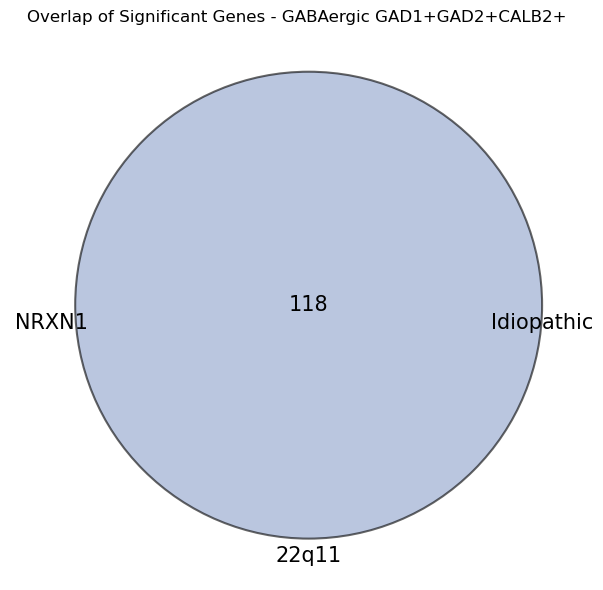

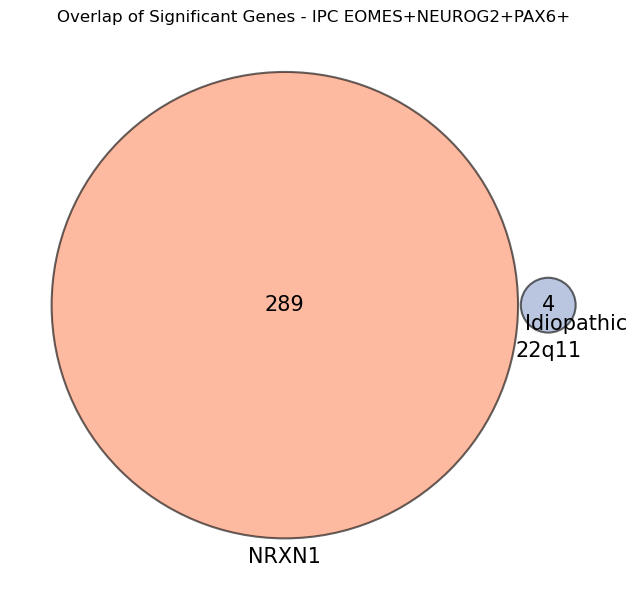

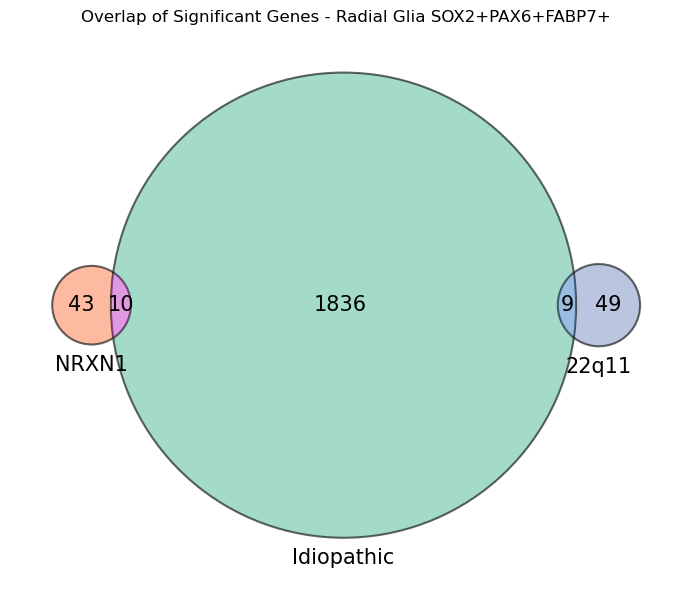

/home/deepak/pixi_envs/scanpy/.pixi/envs/default/lib/python3.12/site-packages/matplotlib_venn/layout/venn3/pairwise.py:107: UserWarning: Circle B has zero area.
  warnings.warn("Circle B has zero area.")


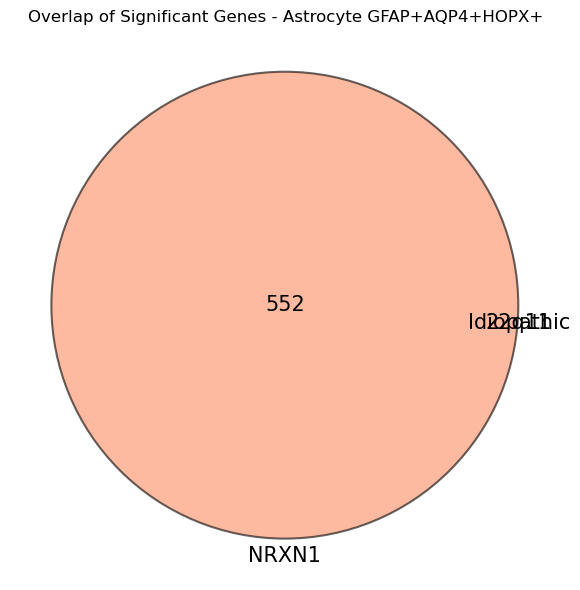

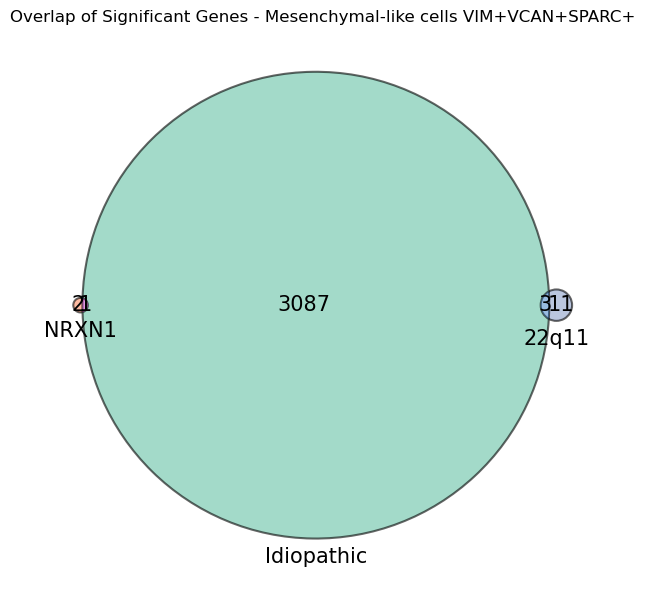

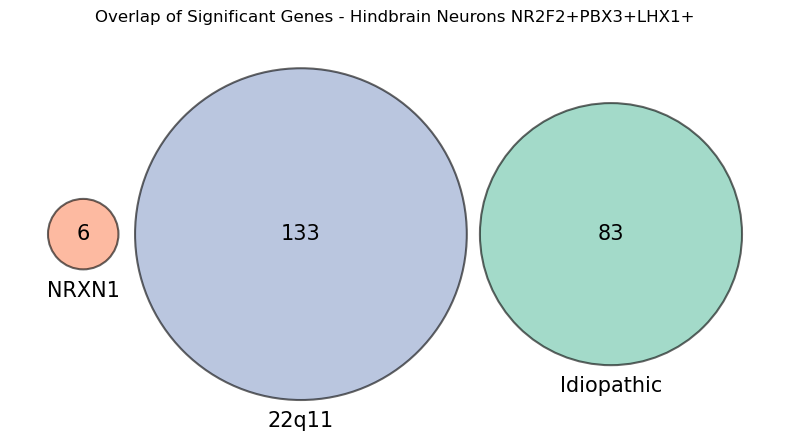

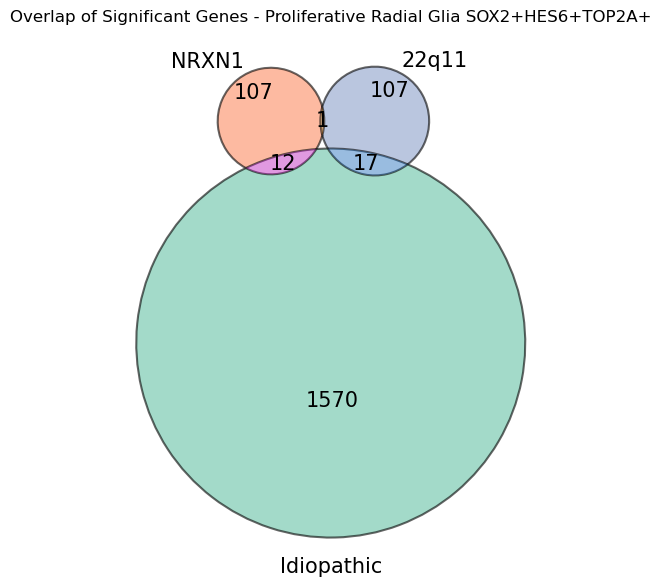

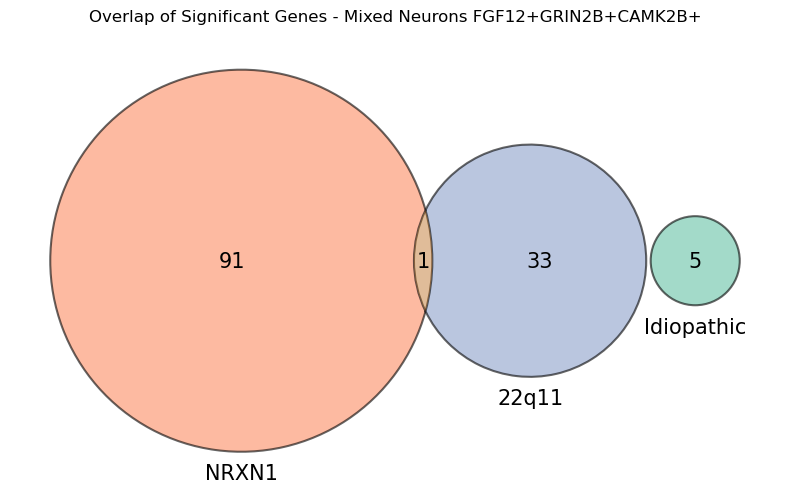

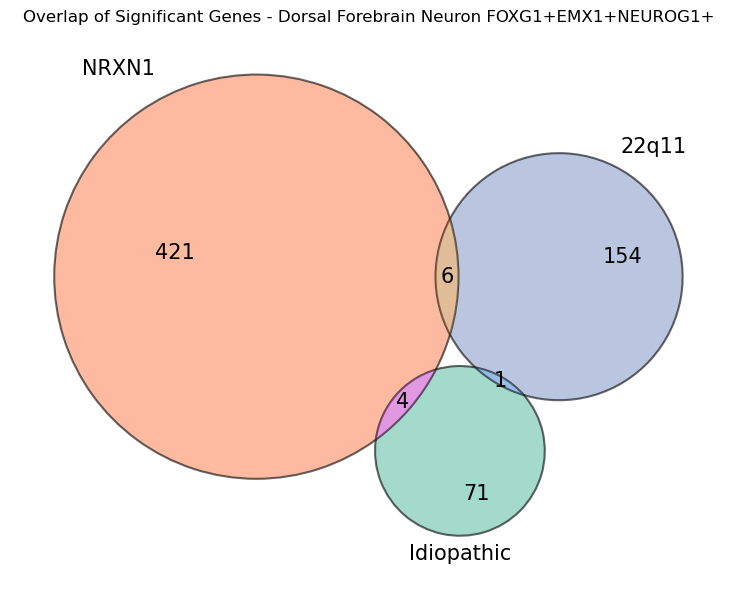

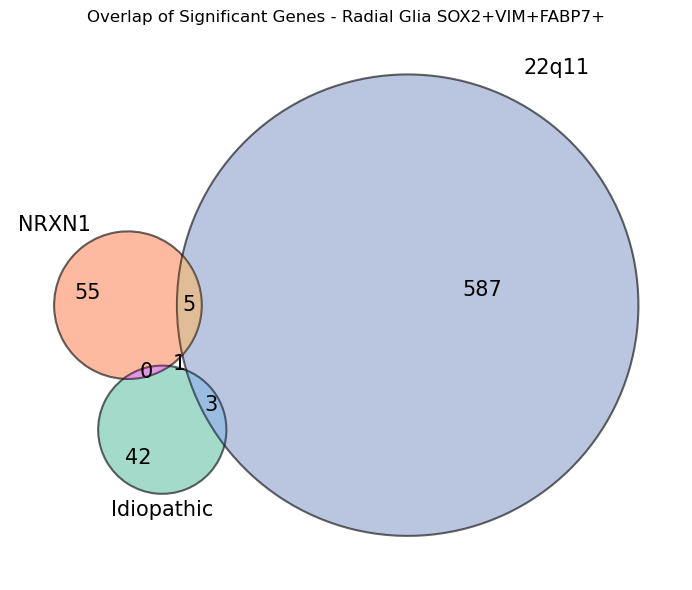

In [16]:
# Convert to sets

celltypes = set(dge_idiopathic['assay']).union(set(dge_22q11['assay'])).union(set(dge_nrxn1['assay']))

# Custom colors
COLORS = {"NRXN1": "#fc8d62ff", "22q11": "#8da0cbff", "Idiopathic": "#66c2a5ff"}
def safe_style_patch(v, pid, color):
    patch = v.get_patch_by_id(pid)
    if patch is not None:
        patch.set_color(color)
        patch.set_alpha(0.6)
        patch.set_edgecolor('black')
        patch.set_linewidth(1.5)

# -----------------------------
# LOOP OVER CELLTYPES
# -----------------------------
for celltype in celltypes:

    idiopathic_filter = set(
        dge_idiopathic[(dge_idiopathic['assay'] == celltype) & dge_idiopathic['significant_fdr']]['ID']
    )
    x22q11_filter = set(
        dge_22q11[(dge_22q11['assay'] == celltype) & dge_22q11['significant_fdr']]['ID']
    )
    nrxn1_filter = set(
        dge_nrxn1[(dge_nrxn1['assay'] == celltype) & dge_nrxn1['significant_fdr']]['ID']
    )

    plt.figure(figsize=(8, 6))

    v = venn3(
        [nrxn1_filter, x22q11_filter, idiopathic_filter],
        set_labels=('NRXN1', '22q11', 'Idiopathic')
    )

    # -----------------------------
    # STYLE SET REGIONS SAFELY
    # -----------------------------
    safe_style_patch(v, '100', COLORS["NRXN1"])
    safe_style_patch(v, '010', COLORS["22q11"])
    safe_style_patch(v, '001', COLORS["Idiopathic"])

    # -----------------------------
    # STYLE LABELS SAFELY
    # -----------------------------
    if v.set_labels:
        for text in v.set_labels:
            if text:
                text.set_fontsize(15)

    if v.subset_labels:
        for text in v.subset_labels:
            if text:
                text.set_fontsize(15)

    plt.title(f"Overlap of Significant Genes - {celltype}")
    plt.savefig(f"/home/deepak/datasets/scz_meta_analysis/panels/Fig_4_{celltype}_venn.svg", bbox_inches='tight')
    plt.tight_layout()
    plt.show()

In [17]:
# ## Without DC ##

# dge_nrxn1_set = set(dge_nrxn1['ID'])
# dge_22q11_set = set(dge_22q11['ID'])
# dge_idiopathic_set = set(dge_idiopathic['ID'])

# # Custom colors
# COLORS = {
#     "NRXN1": "#fc8d62ff",
#     "22q11": "#8da0cbff",
#     "Idiopathic": "#66c2a5ff"
# }

# plt.figure(figsize=(8, 6))

# v = venn3(
#     [dge_nrxn1_set, dge_22q11_set, dge_idiopathic_set],
#     set_labels=('NRXN1', '22q11', 'Idiopathic')
# )

# # =====================================================
# # MAIN SET COLORS + EDGES
# # =====================================================

# v.get_patch_by_id('100').set_color(COLORS["NRXN1"])
# v.get_patch_by_id('100').set_alpha(0.6)
# v.get_patch_by_id('100').set_edgecolor('black')
# v.get_patch_by_id('100').set_linewidth(1.5)

# v.get_patch_by_id('010').set_color(COLORS["22q11"])
# v.get_patch_by_id('010').set_alpha(0.6)
# v.get_patch_by_id('010').set_edgecolor('black')
# v.get_patch_by_id('010').set_linewidth(1.5)

# v.get_patch_by_id('001').set_color(COLORS["Idiopathic"])
# v.get_patch_by_id('001').set_alpha(0.6)
# v.get_patch_by_id('001').set_edgecolor('black')
# v.get_patch_by_id('001').set_linewidth(1.5)

# # =====================================================
# # LABEL STYLING (optional polish)
# # =====================================================

# for text in v.set_labels:
#     if text:
#         text.set_fontsize(15)

# for text in v.subset_labels:
#     if text:
#         text.set_fontsize(15)

# plt.title("Overlap of Significant Genes")
# plt.tight_layout()
# plt.savefig(f"/home/deepak/datasets/scz_meta_analysis/panels/Fig_4_all_celltypes_venn.svg", bbox_inches='tight')
# plt.show()

In [18]:
significant_all = pd.concat([dge_idiopathic.assign(group='Idiopathic Schizophrenia'),
                                dge_nrxn1.assign(group='NRXN1del'), 
                                dge_22q11.assign(group='22q11.2del')], axis=0)

significant_all = significant_all[significant_all['significant_fdr']]

In [19]:
dge_3q29['significant_fdr'] = (dge_3q29['adj.P.Val'] < 0.05)

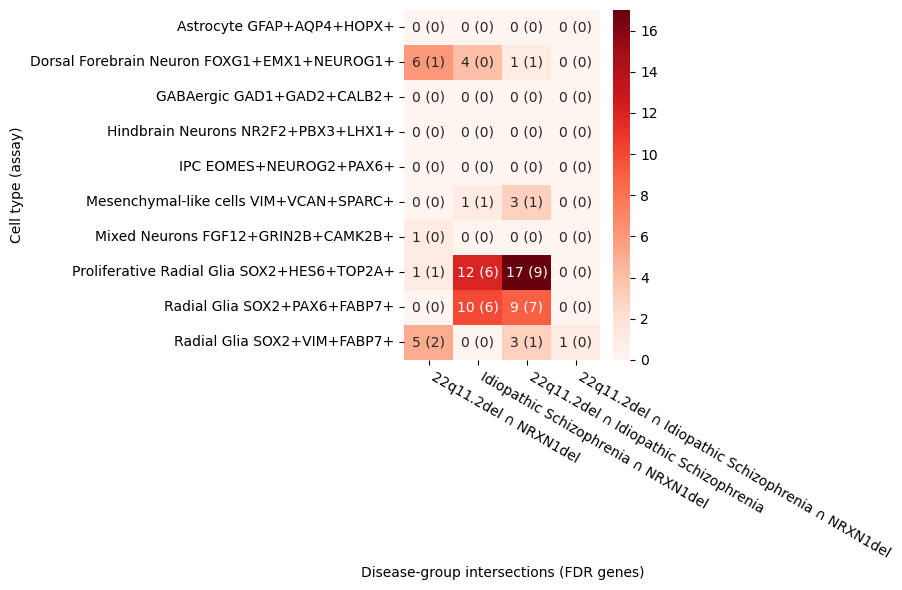

In [20]:
## Generate Counts Heatmap 3#

df = significant_all.copy()
df = df[df["significant_fdr"]]

# -------------------------------------------------------
# 1. gene → group set within assay
# -------------------------------------------------------
gene_group_map = (
    df.groupby(["assay", "ID"])["group"]
      .apply(lambda x: frozenset(x.unique()))
      .reset_index(name="group_set")
)

def label(gs):
    gs = tuple(sorted(gs))
    if len(gs) == 1:
        return gs[0]
    return " ∩ ".join(gs)

gene_group_map["intersection"] = gene_group_map["group_set"].apply(label)

# -------------------------------------------------------
# 2. attach estimates to detect direction
# -------------------------------------------------------
gene_estimate = (
    df.groupby(["assay", "ID"])["estimate"]
      .apply(list)
      .reset_index(name="estimates")
)

gene_group_map = gene_group_map.merge(
    gene_estimate,
    on=["assay", "ID"],
    how="left"
)

# -------------------------------------------------------
# 3. direction consistency (same sign across all rows)
# -------------------------------------------------------
def direction_agree(vals):
    vals = [v for v in vals if pd.notnull(v)]
    if len(vals) == 0:
        return 0
    return int(all(v > 0 for v in vals) or all(v < 0 for v in vals))

gene_group_map["direction_ok"] = gene_group_map["estimates"].apply(direction_agree)

# -------------------------------------------------------
# 4. build counts + directional counts
# -------------------------------------------------------
count_mat = pd.crosstab(
    gene_group_map["assay"],
    gene_group_map["intersection"]
)

dir_mat = gene_group_map.groupby(["assay", "intersection"])["direction_ok"].sum().unstack(fill_value=0)

# keep only intersections (no "only")
cols = [c for c in count_mat.columns if "∩" in c]
count_mat = count_mat[cols]
dir_mat = dir_mat.reindex(columns=cols, fill_value=0)

# -------------------------------------------------------
# 5. build annotation "x (y)"
# -------------------------------------------------------
annot = count_mat.astype(str) + " (" + dir_mat.astype(str) + ")"

# -------------------------------------------------------
# 6. plot
# -------------------------------------------------------
plt.figure(figsize=(8,6))
sns.heatmap(
    count_mat[['22q11.2del ∩ NRXN1del',
               'Idiopathic Schizophrenia ∩ NRXN1del', 
               '22q11.2del ∩ Idiopathic Schizophrenia', 
               '22q11.2del ∩ Idiopathic Schizophrenia ∩ NRXN1del']],
    cmap="Reds",
    annot=annot[['22q11.2del ∩ NRXN1del',
               'Idiopathic Schizophrenia ∩ NRXN1del', 
               '22q11.2del ∩ Idiopathic Schizophrenia', 
               '22q11.2del ∩ Idiopathic Schizophrenia ∩ NRXN1del']],
    fmt="",
    cbar=True
)

plt.xlabel("Disease-group intersections (FDR genes)")
plt.xticks(rotation=-30, ha='left')
plt.ylabel("Cell type (assay)")
plt.tight_layout()
plt.show()

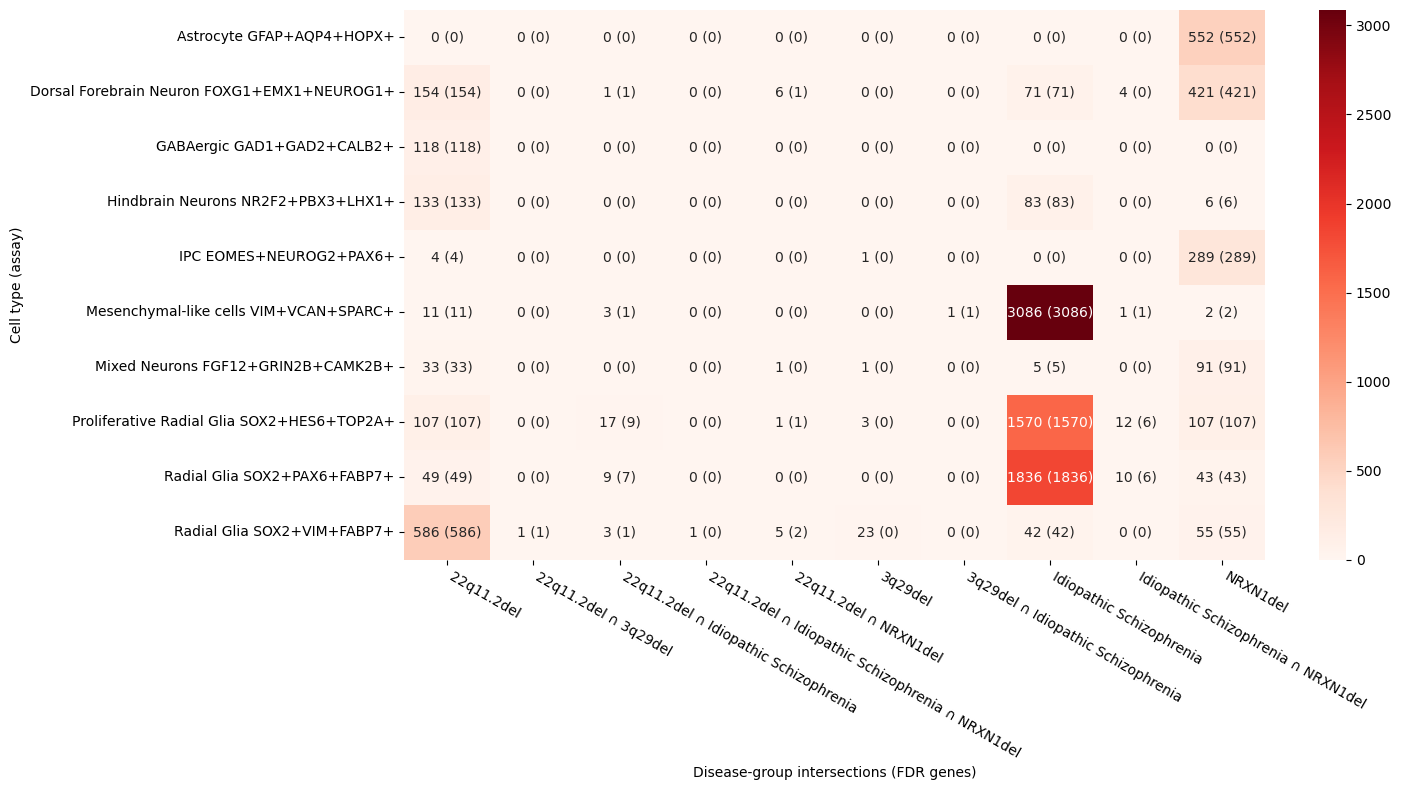

In [21]:
significant_all = pd.concat([dge_idiopathic.assign(group='Idiopathic Schizophrenia'),
                                dge_nrxn1.assign(group='NRXN1del'), 
                                dge_22q11.assign(group='22q11.2del'),
                                dge_3q29.assign(group='3q29del')], axis=0)

significant_all = significant_all[significant_all['significant_fdr']]

df = significant_all.copy()
df = df[df["significant_fdr"]]

# -------------------------------------------------------
# 1. BUILD GENE → GROUP SET
# -------------------------------------------------------
gene_group_map = (
    df.groupby(["assay", "ID"])["group"]
      .apply(lambda x: frozenset(x.unique()))
      .reset_index(name="group_set")
)

# -------------------------------------------------------
# LABEL INTERSECTIONS (NOW INCLUDES 4-WAY)
# -------------------------------------------------------
def label(gs):
    gs = tuple(sorted(gs))
    if len(gs) == 1:
        return gs[0]
    return " ∩ ".join(gs)

gene_group_map["intersection"] = gene_group_map["group_set"].apply(label)

# -------------------------------------------------------
# 2. ATTACH EFFECT ESTIMATES
# -------------------------------------------------------
gene_estimate = (
    df.groupby(["assay", "ID"])["estimate"]
      .apply(list)
      .reset_index(name="estimates")
)

gene_group_map = gene_group_map.merge(
    gene_estimate,
    on=["assay", "ID"],
    how="left"
)

# -------------------------------------------------------
# 3. DIRECTION CONSISTENCY
# -------------------------------------------------------
def direction_agree(vals):
    vals = [v for v in vals if pd.notnull(v)]
    if len(vals) == 0:
        return 0
    return int(all(v > 0 for v in vals) or all(v < 0 for v in vals))

gene_group_map["direction_ok"] = gene_group_map["estimates"].apply(direction_agree)

# -------------------------------------------------------
# 4. BUILD MATRICES (DO NOT FILTER COLUMNS YET)
# -------------------------------------------------------
count_mat = pd.crosstab(
    gene_group_map["assay"],
    gene_group_map["intersection"]
)

dir_mat = (
    gene_group_map
    .groupby(["assay", "intersection"])["direction_ok"]
    .sum()
    .unstack(fill_value=0)
)

# align matrices
dir_mat = dir_mat.reindex_like(count_mat).fillna(0)

# -------------------------------------------------------
# 5. OPTIONAL: SORT COLUMNS (keeps all intersections incl. 4-way)
# -------------------------------------------------------
count_mat = count_mat.loc[:, sorted(count_mat.columns)]
dir_mat = dir_mat.loc[:, count_mat.columns]

# -------------------------------------------------------
# 6. ANNOTATION (COUNT + DIRECTION)
# -------------------------------------------------------
annot = count_mat.astype(str) + " (" + dir_mat.astype(int).astype(str) + ")"

# -------------------------------------------------------
# 7. PLOT
# -------------------------------------------------------
plt.figure(figsize=(15, 8))

sns.heatmap(
    count_mat,
    cmap="Reds",
    annot=annot,
    fmt="",
    cbar=True
)

plt.xlabel("Disease-group intersections (FDR genes)")
plt.ylabel("Cell type (assay)")
plt.xticks(rotation=-30, ha='left')
plt.tight_layout()
plt.show()

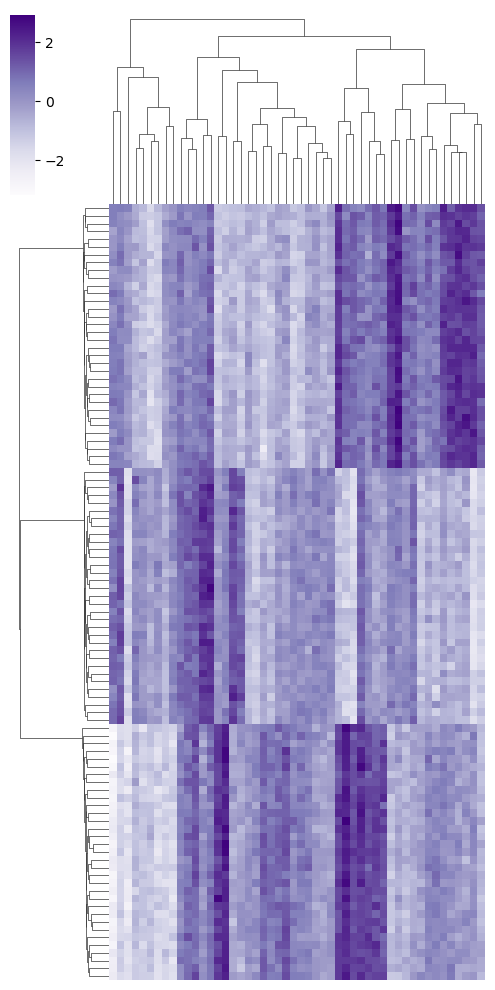

In [22]:
## MashR Schematic ##

np.random.seed(0)

n_genes = 100
n_samples = 50

# create 3 latent signals (3 blocks)
block1 = np.random.randn(n_samples)
block2 = np.random.randn(n_samples)
block3 = np.random.randn(n_samples)

data = np.zeros((n_genes, n_samples))

data[0:33]   = block1 + 0.3 * np.random.randn(33, n_samples)
data[33:66]  = block2 + 0.3 * np.random.randn(33, n_samples)
data[66:100] = block3 + 0.3 * np.random.randn(34, n_samples)

df = pd.DataFrame(
    data,
    index=[f"gene_{i}" for i in range(n_genes)],
    columns=[f"cell_{i}" for i in range(n_samples)]
)

sns.clustermap(
    df,
    cmap="Purples",
    figsize=(5, 10),
    xticklabels=False,
    yticklabels=False
)

plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Fig_4_mashR_schematic.svg", bbox_inches='tight')
plt.show()

In [23]:
def plot_assay_upset(df, set_col='group', gene_col='ID', significance_col='significant_fdr', 
                     min_size=1, dataset_label="", top_graph=True, side_graph=True, title=True, 
                     save=False):

    # filter significant genes
    if significance_col in df.columns:
        df = df[df[significance_col] == True]
    
    assay_sets = {val: set(group[gene_col].dropna().unique())
        for val, group in df.groupby(set_col)}
    
    # remove small sets
    assay_sets = {k: v for k, v in assay_sets.items() if len(v) >= min_size}
    
    # safety check
    if len(assay_sets) < 2:
        print(f"Not enough groups to plot: {list(assay_sets.keys())}")
        return
    
    # convert
    upset_data = from_contents(assay_sets)
    
    plt.figure(figsize=(10, 6))

    if top_graph and side_graph:
        upset = UpSet(upset_data, show_counts=True, sort_by='degree')
    elif top_graph and not side_graph:
        upset = UpSet(upset_data, show_counts=True, with_lines=True, element_size=49, totals_plot_elements=0)
    elif side_graph and not top_graph:
        upset = UpSet(upset_data, show_counts=True, with_lines=True, element_size=49, intersection_plot_elements=())
    else:
        upset = UpSet(upset_data, show_counts=True, with_lines=True, element_size=49, intersection_plot_elements=(), totals_plot_elements=0)
    
    upset.plot()

    if title:
        plt.suptitle(f"{dataset_label} Shared DGEs")
        
    if save:
        plt.savefig(f"/home/deepak/datasets/scz_meta_analysis/panels/Fig_4_{dataset_label}_upset_.svg")
    
    plt.show()

In [24]:
significant_all_rg_pax6 = significant_all[significant_all['assay'] == 'Radial Glia SOX2+PAX6+FABP7+']
significant_all_prg = significant_all[significant_all['assay'] == 'Proliferative Radial Glia SOX2+HES6+TOP2A+']
significant_all_rg_vim = significant_all[significant_all['assay'] == 'Radial Glia SOX2+VIM+FABP7+']
significant_all_ipc = significant_all[significant_all['assay'] == 'IPC EOMES+NEUROG2+PAX6+']
significant_all_dorsal = significant_all[significant_all['assay'] == 'Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+']
significant_all_mixed = significant_all[significant_all['assay'] == 'Mixed Neurons FGF12+GRIN2B+CAMK2B+']
significant_all_hindbrain = significant_all[significant_all['assay'] == 'Hindbrain Neurons NR2F2+PBX3+LHX1+']
significant_all_mc = significant_all[significant_all['assay'] == 'Mesenchymal-like cells VIM+VCAN+SPARC+']
significant_all_astro = significant_all[significant_all['assay'] == 'Astrocyte GFAP+AQP4+HOPX+']
significant_all_gaba = significant_all[significant_all['assay'] == 'GABAergic GAD1+GAD2+CALB2+']

<Figure size 1000x600 with 0 Axes>

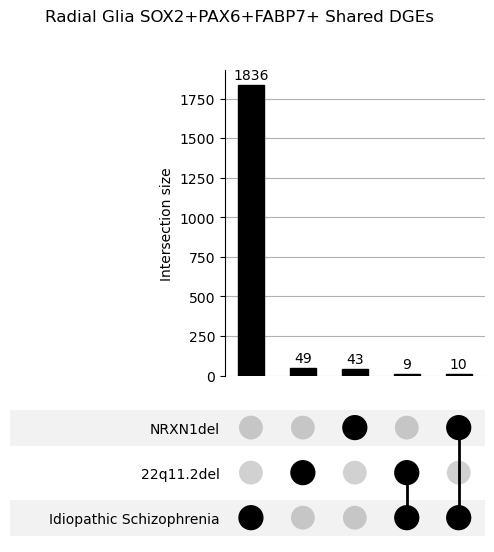

In [25]:
plot_assay_upset(significant_all_rg_pax6,  dataset_label="Radial Glia SOX2+PAX6+FABP7+", 
                 set_col='group', top_graph=True, side_graph=False, save=True)

<Figure size 1000x600 with 0 Axes>

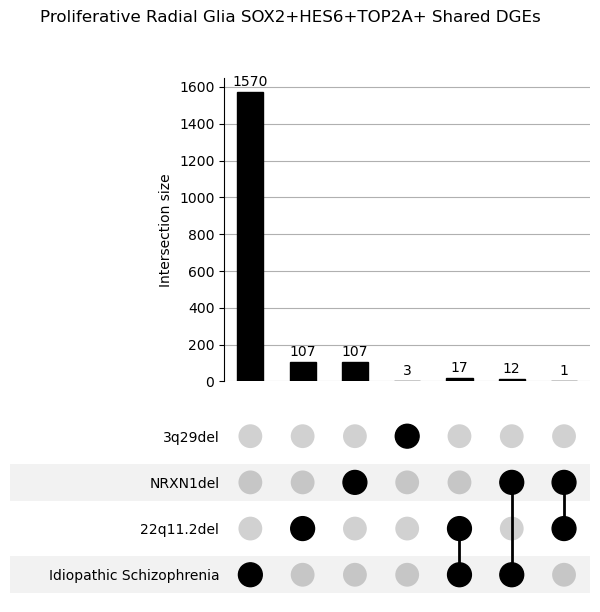

In [26]:
plot_assay_upset(significant_all_prg, dataset_label="Proliferative Radial Glia SOX2+HES6+TOP2A+", 
                 set_col='group', top_graph=True, side_graph=False, save=True)

<Figure size 1000x600 with 0 Axes>

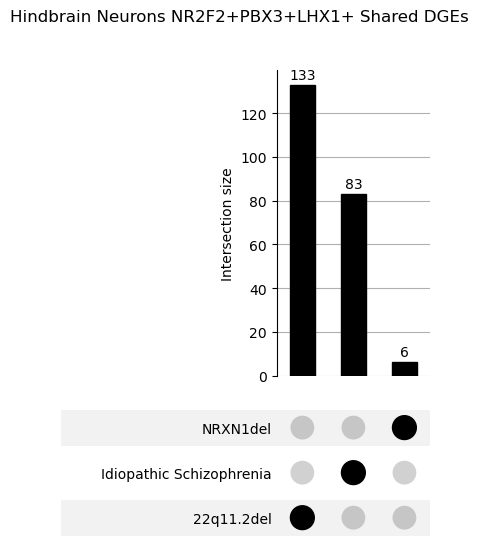

In [27]:
plot_assay_upset(significant_all_hindbrain, dataset_label="Hindbrain Neurons NR2F2+PBX3+LHX1+",
                 set_col='group', top_graph=True, side_graph=False, save=True)

<Figure size 1000x600 with 0 Axes>

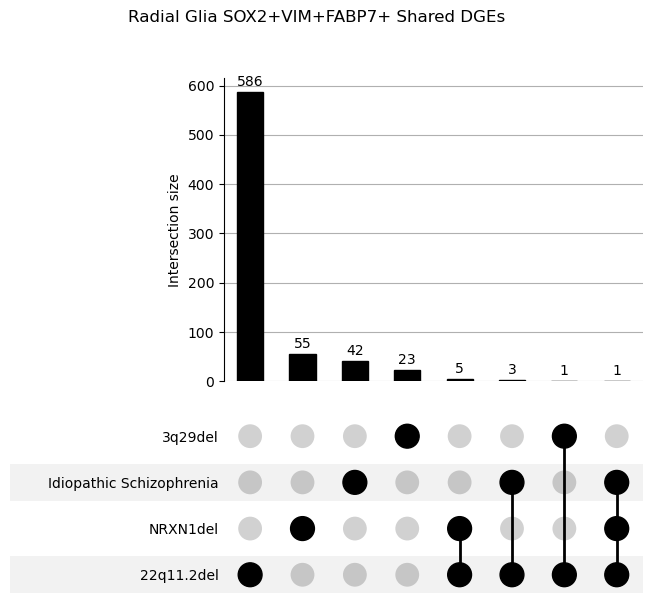

In [28]:
plot_assay_upset(significant_all_rg_vim, dataset_label="Radial Glia SOX2+VIM+FABP7+", set_col='group',
                 top_graph=True, side_graph=False, save=True)

<Figure size 1000x600 with 0 Axes>

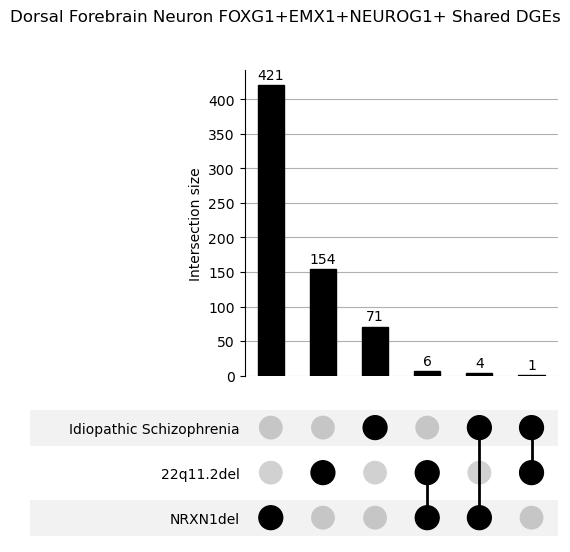

In [29]:
plot_assay_upset(significant_all_dorsal, dataset_label="Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+",
                 set_col='group', top_graph=True, side_graph=False, save=True)

<Figure size 1000x600 with 0 Axes>

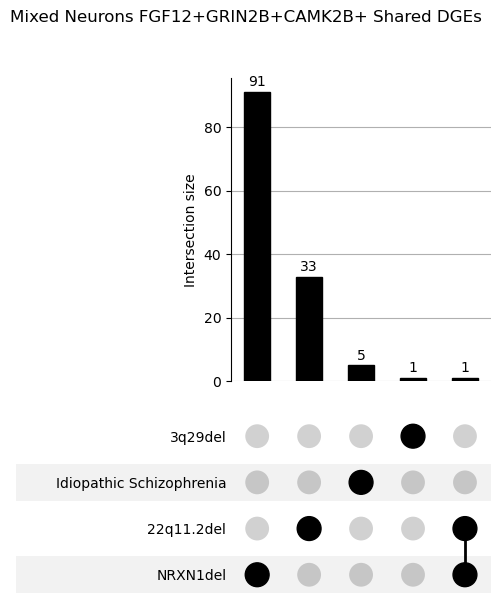

In [30]:
plot_assay_upset(significant_all_mixed, dataset_label="Mixed Neurons FGF12+GRIN2B+CAMK2B+",  
                 set_col='group', top_graph=True, side_graph=False, save=True)

In [31]:
plot_assay_upset(significant_all_astro, dataset_label="Astrocyte",  
                 set_col='group', top_graph=True, side_graph=False, save=True)

Not enough groups to plot: ['NRXN1del']


<Figure size 1000x600 with 0 Axes>

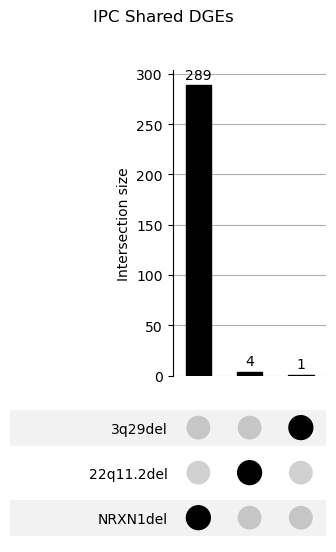

In [32]:
plot_assay_upset(significant_all_ipc, dataset_label="IPC",  
                 set_col='group', top_graph=True, side_graph=False, save=True)

<Figure size 1000x600 with 0 Axes>

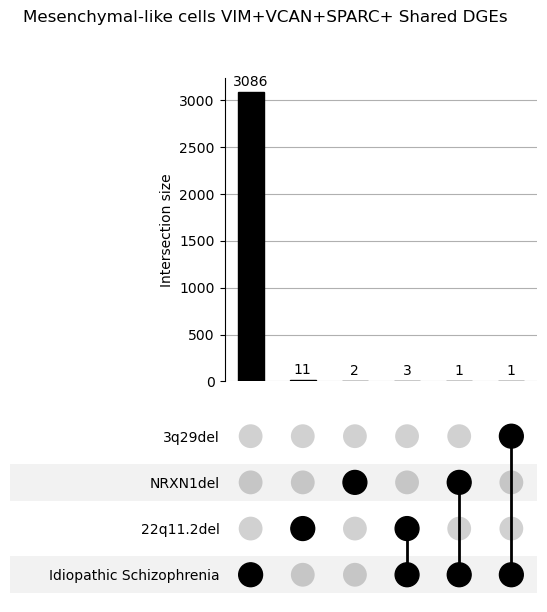

In [33]:
plot_assay_upset(significant_all_mc, dataset_label="Mesenchymal-like cells VIM+VCAN+SPARC+",  
                 set_col='group', top_graph=True, side_graph=False, save=True)

In [34]:
plot_assay_upset(significant_all_gaba, dataset_label="GABA",  
                 set_col='group', top_graph=True, side_graph=False, save=True)

Not enough groups to plot: ['22q11.2del']


In [35]:
## Import Posterior Tests from mashR ##

dfn_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_Dorsal_Forebrain_Neuron_FOXG1+EMX1+NEUROG1+_all.csv')
rg_vim_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_Radial_Glia_SOX2+VIM+FABP7+_all.csv')
rg_pax_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_Radial_Glia_SOX2+PAX6+FABP7+_all.csv')
mc_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_Mesenchymal-like_cells_VIM+VCAN+SPARC+_all.csv')
gaba_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_GABAergic_GAD1+GAD2+CALB2+_all.csv')
prg_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_Proliferative_Radial_Glia_SOX2+HES6+TOP2A+_all.csv')
ipc_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_IPC_EOMES+NEUROG2+PAX6+_all.csv')
mn_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_Mixed_Neurons_FGF12+GRIN2B+CAMK2B+_all.csv')
astro_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_Astrocyte_GFAP+AQP4+HOPX+_all.csv')

In [36]:
idiopathic_sig = significant_all[significant_all['group'] == 'Idiopathic Schizophrenia']
x22q11_sig = significant_all[significant_all['group'] == '22q11.2del']
nrxn1_sig = significant_all[significant_all['group'] == 'NRXN1del']

In [37]:
combined = pd.DataFrame({
    "gene": dfn_composite["gene"],
    "score_dfn": dfn_composite["score"],
    "score_rg_vim": rg_vim_composite["score"],
    "score_rg_pax": rg_pax_composite["score"],
    "score_mc": mc_composite["score"],
    "score_gaba": gaba_composite["score"],
    "score_prg": prg_composite["score"],
    "score_ipc": ipc_composite["score"],
    "score_mn": mn_composite["score"],
    "score_astro": astro_composite["score"],
})

combined = combined.set_index("gene")

combined.to_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/combined_composite_test.csv')

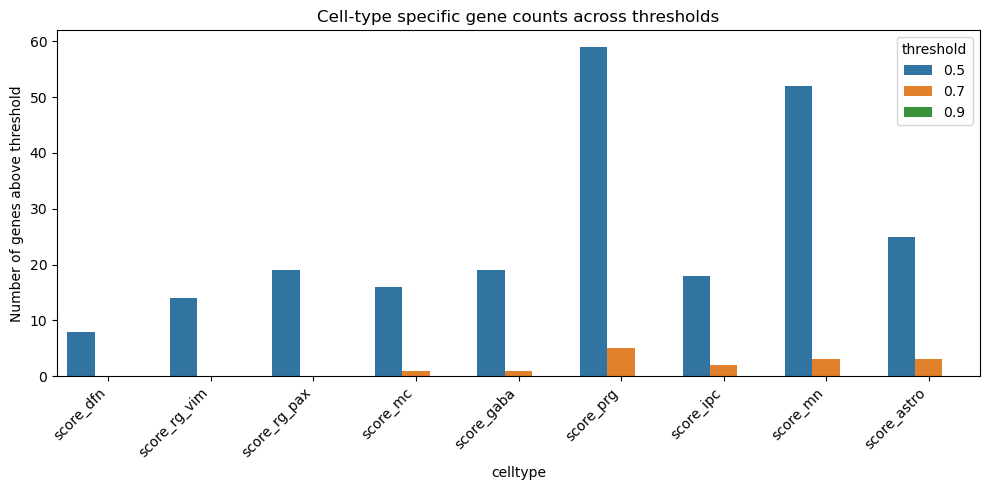

In [38]:
thresholds = [0.5, 0.7, 0.9]

data = []

for t in thresholds:
    counts = (combined > t).sum(axis=0)  # per cell type
    for celltype, value in counts.items():
        data.append({
            "celltype": celltype,
            "threshold": str(t),
            "count": value
        })

df = pd.DataFrame(data)


plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="celltype",
    y="count",
    hue="threshold"
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of genes above threshold")
plt.title("Cell-type specific gene counts across thresholds")
plt.tight_layout()

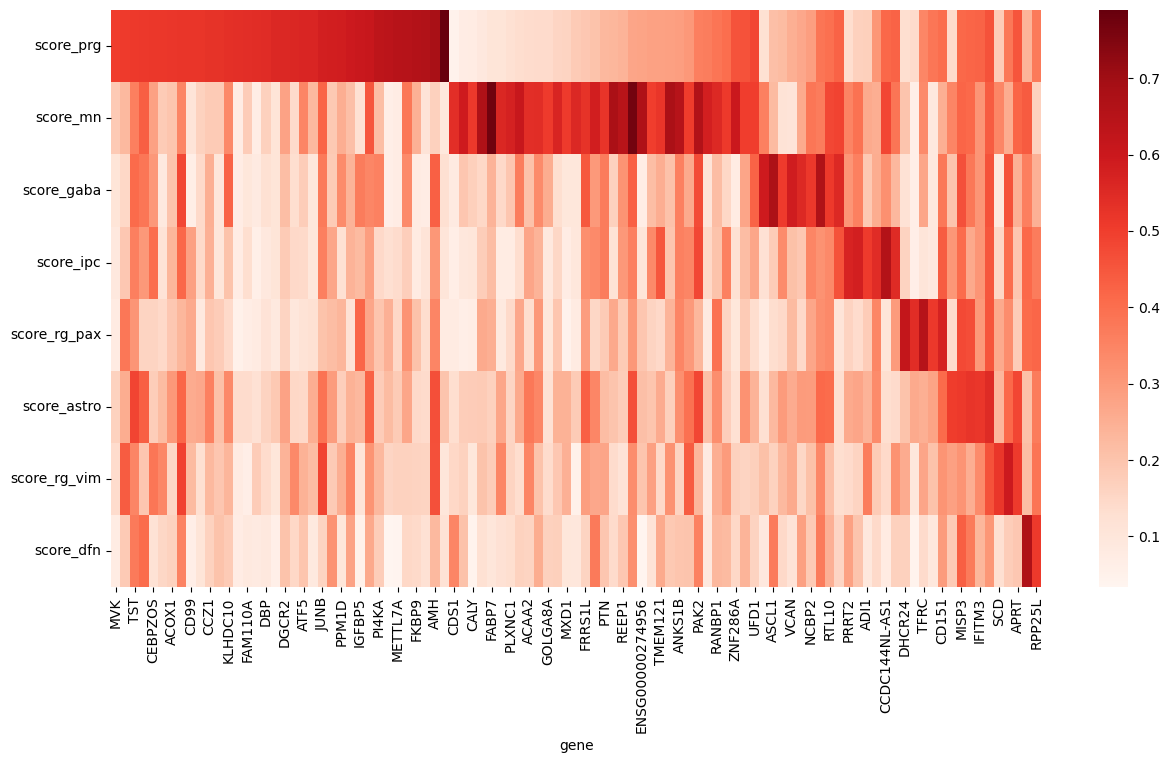

In [39]:
specific = combined[(combined > 0.5).sum(axis=1) == 1]

winner = (specific > 0.5).idxmax(axis=1)

# Count how many genes belong to each cell type
block_sizes = winner.value_counts()

# Order cell types from largest block to smallest
col_order = block_sizes.index.tolist()

# Reorder columns
specific = specific[col_order]

# Make winner a categorical with the desired ordering
winner = pd.Categorical(
    winner,
    categories=col_order,
    ordered=True
)

# Sort rows by block, then by score within each block
specific = (
    specific.assign(winner=winner)
            .sort_values(["winner"] + col_order, ascending=False)
            .drop(columns="winner")
)

specific = specific.iloc[::-1]

plt.figure(figsize=(15,7.5))
sns.heatmap(specific.T, yticklabels=True, cmap='Reds')
plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Fig_4_mashR_Heatmap.svg", bbox_inches='tight')

In [40]:
## Prep GO Plots On Mash Result ##

celltype_gene_mash_df = pd.DataFrame([[i.removeprefix('score_') for i in winner], specific.index], index=['celltype', 'gene']).T
mash_gseapy_dict = celltype_gene_mash_df.groupby('celltype').agg(list)['gene'].to_dict()

enrichr_results = []

for celltype in mash_gseapy_dict.keys():
    res = gp.enrichr(
        gene_list=mash_gseapy_dict[celltype],
        gene_sets='GO_Biological_Process_2026',
        organism='hs'
    ).results.copy()

    # add label
    res['celltype'] = celltype

    enrichr_results.append(res)

    time.sleep(1.5)

# combine everything
enrich_df = pd.concat(enrichr_results, ignore_index=True)

enrich_df['Term_cleaned'] = enrich_df['Term'].str.replace(r'\s*\(GO:[^)]+\)$', '', regex=True).str.strip()

enrich_df['neglogP'] = -np.log10(enrich_df['Adjusted P-value'])

/tmp/ipykernel_28672/2981337544.py:23: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  enrich_df = pd.concat(enrichr_results, ignore_index=True)


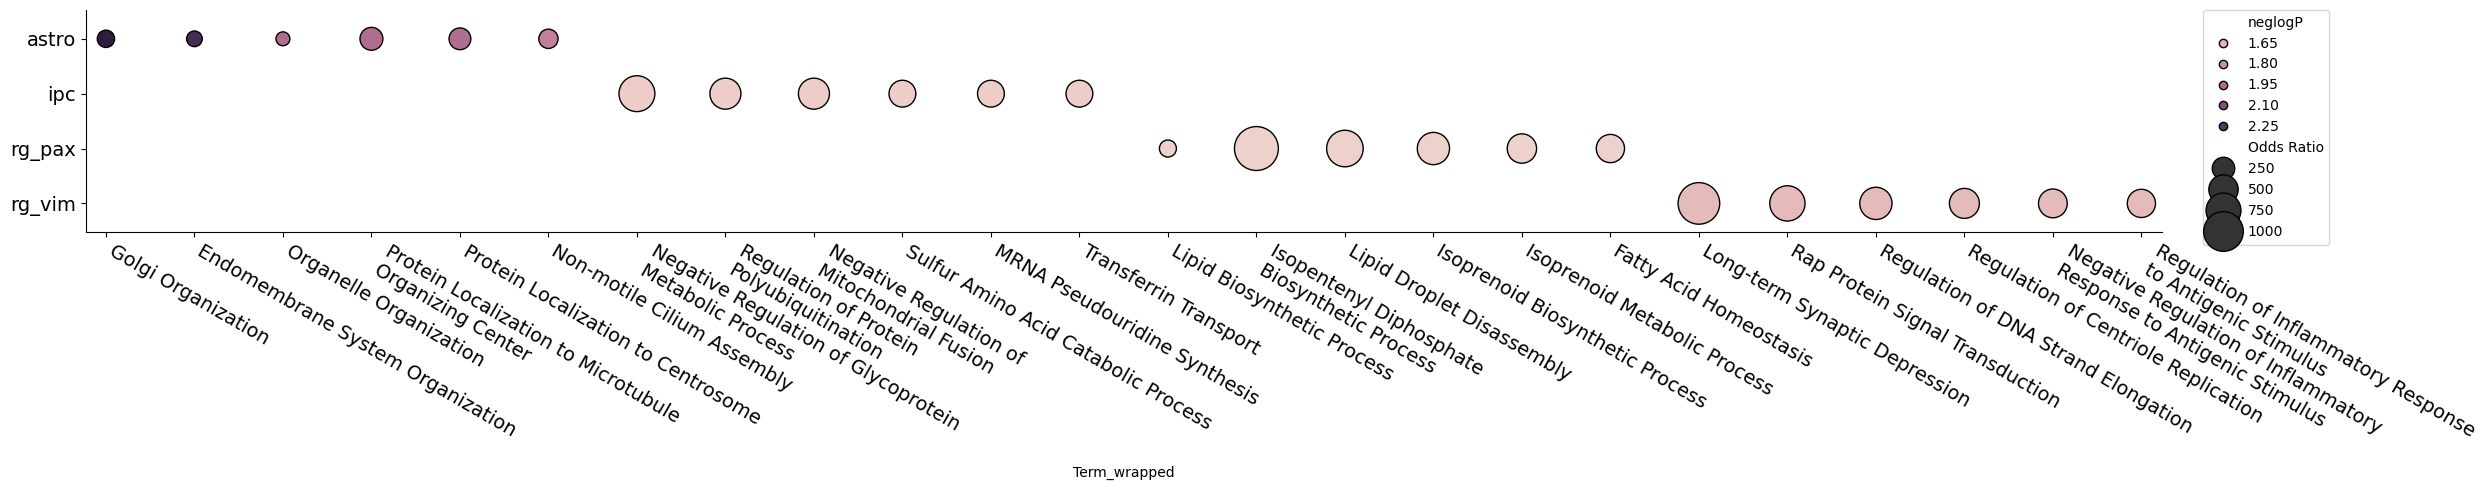

In [41]:
## Plot GO Terms ##

df = enrich_df[enrich_df['Adjusted P-value'] < 0.05].groupby('celltype').head(6).copy()

df["Term_wrapped"] = df["Term_cleaned"].apply(
    lambda x: "\n".join(textwrap.wrap(x, width=35))
)

plt.figure(figsize=(25, 5))

ax = sns.scatterplot(
    data=df,
    y='celltype',
    x='Term_wrapped',
    size='Odds Ratio',
    sizes=(100, 1000),
    hue='neglogP',
    edgecolor="black", linewidth=1.,
)

plt.xticks(rotation=-30, ha='left')

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0
)

ax.set_ylabel('')
ax.margins(x=0.01)  
ax.margins(y=.175)  
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
for label in ax.get_yticklabels():
    label.set_fontweight('medium')
sns.despine(top=True, right=True)
plt.tight_layout()
plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Fig_4_mashR_GO_dotplot.svg", bbox_inches='tight')
plt.show()